In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
from math import ceil
import socket
import scipy.signal as signal
import glob
import time
from random import randint
%matplotlib widget

In [8]:
# Path to get to /home/rfsoc
home_dir = Path("./../../..")
os.chdir(home_dir)

# Paths relative to /home/rfsoc
primecam_readout = Path('./primecam_readout')
ccatkidlib = Path('./ccatkidlib')
data_dir = Path('./../../mnt/md0')

# Append paths
sys.path.insert(0, os.path.abspath(ccatkidlib / 'rfsoc')) # Path contaning rfsoc_daq

In [5]:
%load_ext autoreload
%autoreload 2

from rfsoc_daq import R
import rfsoc_io
from rfsoc_timestream import Streamer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
# Data Directory Name
data_name = 'bath_sweep_data'
date = '20241211'
sess_id = '1733957904'#1733488765'

In [10]:
# Load init IO config
io_cfg_name = f'init_config_io_{sess_id}.yaml'
cfg_dir = data_dir / data_name / 'rfsoc' / date / sess_id

io_cfg = rfsoc_io.load_config(cfg_dir / io_cfg_name)
print(io_cfg.keys())

dict_keys(['sess_id', 'drone_list', 'initialize', 'parallel', 'restart', 'udp_ip', 'udp_port', 'boards', 'file_paths', 'file_names', 'pcs_agents', 'io'])


In [26]:
# Gather all vna timestamps
def all_timestamps(cfg_dir):
    all_timestamps = {'vna':[], 'targ':[], 'stream':[]}

    for cfg_file in np.sort(glob.glob(str(cfg_dir / "vna_config_ext_*.yaml"))):
        ctime = cfg_file.split('/vna_config_ext_')[1].split(".yaml")[0]
        all_timestamps['vna'].append(ctime)
    
    for cfg_file in np.sort(glob.glob(str(cfg_dir / "target_config_ext_*.yaml"))):
        ctime = cfg_file.split('/target_config_ext_')[1].split(".yaml")[0]
        all_timestamps['targ'].append(ctime)
    
    for cfg_file in np.sort(glob.glob(str(cfg_dir / "timestream_config_ext_*.yaml"))):
        ctime = cfg_file.split('/timestream_config_ext_')[1].split(".yaml")[0]
        all_timestamps['stream'].append(ctime)
        
    return all_timestamps

def config_dir(date, sess_id, data_dir, data_name):
    io_cfg_name = f'init_config_io_{sess_id}.yaml'
    cfg_dir = data_dir / data_name / 'rfsoc' / date / sess_id
    return cfg_dir

In [65]:
cfg_dir = config_dir(date, sess_id, data_dir, data_name)
timestamps = all_timestamps(cfg_dir)
Masterlist = collect_all_files(timestamps, cfg_dir, load_configs = True, vna_only = True)

In [28]:
#Gather all data for given timestamp

def collect_all_files(all_timestamps, cfg_dir, load_configs = False, vna_only = False):
    '''
    take a dictionary of all timestamps, groups all data, gathers the location of data and config files
    optionally loads all configs

    Takes a dictionary of all timestamps, and a config directory

    Returns dictionaries for vna, target sweep, and timestreams associated with timestamp. Within those dicts, the key data is:

    'ext_cfg': 'array_temp', 'coldload_temp', and 'power_supply_voltage'
    'dr_cfg': Need to specify drone (e.g. B1D1) but then you'll get
        'atten': attenuation set up
        'tones': 'NCLO', 'bandwidth', 'N_step', 'dB', 'num_tones', 'tone_freqs', 'tone_powers', 'tone_phis'
        'det_config': 'detector_type', 'nominal_num_detectors', 'nominal_detector_freqs', 'found_num_detectors', 'found_detector_freqs'
        'det_find': same argument options used in primecam_readout
    'data_files': the actual numpy files for loading
    '''

    Masterlist = {}
    
    #Groups all files
    keys = all_timestamps['vna']
    final = max([int(all_timestamps['targ'][-1]), int(all_timestamps['stream'][-1])]) +1
    bookends = np.array([int(t) for t in keys[1:] + [final]])
    all_targs = np.array([int(t) for t in all_timestamps['targ']])
    all_streams = np.array([int(t) for t in all_timestamps['stream']])
    
    for key, bookend in zip(keys, bookends):
        targ_times = list(filter(lambda x: (x>=int(key))and(x<bookend), all_targs))
        stream_times = list(filter(lambda x: (x>=int(key))and(x<bookend), all_streams))
        vna_files = {'ext_file': load_cfgs(key, cfg_dir, files_only=True), 
                'dr_files': load_cfgs(key, cfg_dir, drone=True, files_only=True), 
                'data_files':grab_data_files(key, cfg_dir, 'vna')}
        key_dict = {'targ_times':targ_times ,'stream_times':stream_times, 'vna_files':vna_files}
        if load_configs:
            vna_cfgs = {'ext_cfg': load_cfgs(key, cfg_dir), 'dr_cfg': load_cfgs(key, cfg_dir, drone=True)}
            key_dict['vna_cfgs']=vna_cfgs
        Masterlist[key]=key_dict

    if vna_only:
        return Masterlist
        
    #Setup file dictionaries and load configs
    for key in keys:
        targ_times = Masterlist[key]['targ_times']
        targ_dict = {}

        for targ_time in targ_times:
            targ_time = str(targ_time)
            targ_files = {'ext_file': load_cfgs(targ_time, cfg_dir, files_only=True), 
                'dr_files': load_cfgs(targ_time, cfg_dir, drone=True, files_only=True), 
                'data_files': grab_data_files(targ_time, cfg_dir, 'targ')}
            targ_dict[targ_time] = {'targ_files':targ_files}
            if load_configs:
                targ_cfgs = {'ext_cfg': load_cfgs(targ_time, cfg_dir), 'dr_cfg': load_cfgs(targ_time, cfg_dir, drone=True)}
                targ_dict[targ_time]['targ_cfgs']=targ_cfgs 

        stream_times = Masterlist[key]['stream_times']
        stream_dict = {}

        for stream_time in stream_times:
            stream_time = str(stream_time)
            stream_files = {'ext_file': load_cfgs(stream_time, cfg_dir, files_only=True), 
                'dr_files': load_cfgs(stream_time, cfg_dir, drone=True, files_only=True), 
                'data_files': grab_data_files(stream_time, cfg_dir, 'targ')}
            stream_dict[stream_time] = {'stream_files':stream_files}
            if load_configs:
                stream_cfgs = {'ext_cfg': load_cfgs(stream_time, cfg_dir), 'dr_cfg': load_cfgs(stream_time, cfg_dir, drone=True)}
                stream_dict[stream_time]['stream_cfgs']=stream_cfgs 
        
        Masterlist[key]['targ_dict']=targ_dict
        Masterlist[key]['stream_dict']=stream_dict

                       
    return Masterlist

def load_cfgs(tstamp, cfg_dir, drone=False, files_only=False):
    '''
    Load config files, either drone or external
    '''
    if drone:
        io_cfg = rfsoc_io.load_config(glob.glob(str(cfg_dir / "init_config_io_*.yaml"))[0])
        drone_list = io_cfg['drone_list']

        drone_cfgs = {}

        for dnum in drone_list:
            bid, drid = dnum.split('.')
            dkey = f'B{bid}D{drid}'
            d_cfg_file = glob.glob(str(cfg_dir / dkey / f"*_config_drone_{tstamp}.yaml"))[0]
            if files_only:
                d_cfg = d_cfg_file
            else:
                d_cfg = rfsoc_io.load_config(d_cfg_file)
            drone_cfgs[dkey] = d_cfg
        return drone_cfgs
        
    ext_cfg_file = glob.glob(str(cfg_dir / f"*_config_ext_{tstamp}.yaml"))[0]
    if files_only:
        return ext_cfg_file
    ext_config = rfsoc_io.load_config(ext_cfg_file)
    return ext_config

def grab_data_files(tstamp, cfg_dir, key):
    '''
    Makes a dictionary of the data files of a particular type
    '''
    data_dir = str(cfg_dir).replace("/rfsoc/", "/" + key + "/")
    
    io_cfg = rfsoc_io.load_config(glob.glob(str(cfg_dir / "init_config_io_*.yaml"))[0])
    drone_list = io_cfg['drone_list']

    drone_data = {}
    
    for dnum in drone_list:
        bid, drid = dnum.split('.')
        dkey = f'B{bid}D{drid}'
        drone_dir = data_dir + "/" + dkey + "/"
        datafiles = glob.glob(drone_dir + f"*{tstamp}*")
        drone_data[dkey] = datafiles
    
    return drone_data

In [31]:
# NEED TO ADD A LITE option that skips loading most of the drone config data

IndexError: list index out of range

'1733865336'

In [383]:
t0 = int(list(Masterlist.keys())[0])
for key in Masterlist.keys():
    dc = Masterlist[key]
    clT = dc['vna_cfgs']['ext_cfg']['coldload_temp']
    arT = dc['vna_cfgs']['ext_cfg']['array_temp']
    
    print(clT, arT)

55.835 [0.0821908, 0.0808453]
55.834 [0.0822022, 0.0808623]
55.89 [0.0822115, 0.0808653]
55.838 [0.0822027, 0.0808629]
55.719 [0.0821948, 0.0808599]
55.837 [0.0821943, 0.0808578]
55.84 [0.0821839, 0.0808492]
55.72 [0.0821813, 0.0808547]
55.841 [0.0821875, 0.0808535]
55.722 [0.0821849, 0.0808505]
55.778 [0.0822168, 0.0808819]


In [375]:
Masterlist[key]['vna_cfgs']['ext_cfg']

{'sess_id': '1733488765',
 'power_supply_voltage': 8,
 'array_temp': [0.0826742, 0.081358],
 'coldload_temp': 64.598,
 'bath_temp': None}

In [14]:
def plot_sweep(sweep_file, figax = None, label = "", n = 10, fix_offset=True, smooth = False, phase = False):
    # Create axes object or use passed axes object
    if figax is None:
        fig, ax = plt.subplots(figsize = (8, 8))
    else:
        fig, ax = figax
    
    # Load VNA sweep data
    fs, s21z = np.load(sweep_file)
    fs = np.abs(fs) 
    s21m = np.abs(s21z)
    s21dB = 20*np.log10(s21m)#
    s21_phase = np.angle(s21z)

    if phase:
        s21dB = s21_phase
        fix_offset = False
        
    if fix_offset:
        offset = np.median(signal.medfilt(s21dB, kernel_size = n)[n:])
    else:
        offset = 0
        
    if smooth:
        ax.plot(fs[n:]/1e6, signal.medfilt(s21dB, kernel_size = n)[n:] - offset, label = label)
    else:
        ax.plot(fs/1e6, s21dB- offset, label = label)
    #ax.set_xlabel("Frequency (MHz)")
    #ax.set_ylabel("|S21| (dB)")

    # Create legend if label was provided
    if label != "":
        ax.legend(loc = 1)
        
    return fs, s21z

In [62]:
date_sess_pairs = {'20241208': {'1733663963':{}, '1733694029':{}},
                  '20241209': {'1733771373':{}}, 
                  '20241210': {'1733810508':{}}}
for date in date_sess_pairs.keys():
    for sess_id in date_sess_pairs[date].keys():
        print(date, sess_id)
        cfg_dir = config_dir(date, sess_id, data_dir, data_name)
        timestamps = all_timestamps(cfg_dir)
        print(timestamps)
        Masterlist = collect_all_files(timestamps, cfg_dir, load_configs = True, vna_only = True)
        date_sess_pairs[date][sess_id] = Masterlist
                               

20241208 1733663963
{'vna': ['1733664040', '1733664180', '1733664333', '1733664485', '1733664641', '1733664794', '1733664941', '1733665094', '1733665227', '1733665384', '1733666477', '1733671882', '1733672038', '1733672202', '1733672362', '1733672517', '1733672663', '1733672812', '1733672980', '1733673147', '1733673315', '1733674390', '1733679780', '1733679942', '1733680107', '1733680259', '1733680413', '1733680566', '1733680726', '1733680878', '1733681037', '1733681200', '1733682307', '1733687717', '1733687873', '1733688025', '1733688174', '1733688333'], 'targ': ['1733665805', '1733666056', '1733666920', '1733667167', '1733673731', '1733673971', '1733674811', '1733675060', '1733681631', '1733681881', '1733682749', '1733682993'], 'stream': ['1733666149', '1733667259', '1733674064', '1733675153', '1733681974', '1733683086']}
20241208 1733694029
{'vna': ['1733697201', '1733697357', '1733697508', '1733697655', '1733697804', '1733697957', '1733698113', '1733698262', '1733698415', '17336985

Text(0.5, 0.98, 'VNA Traces: TiN network')

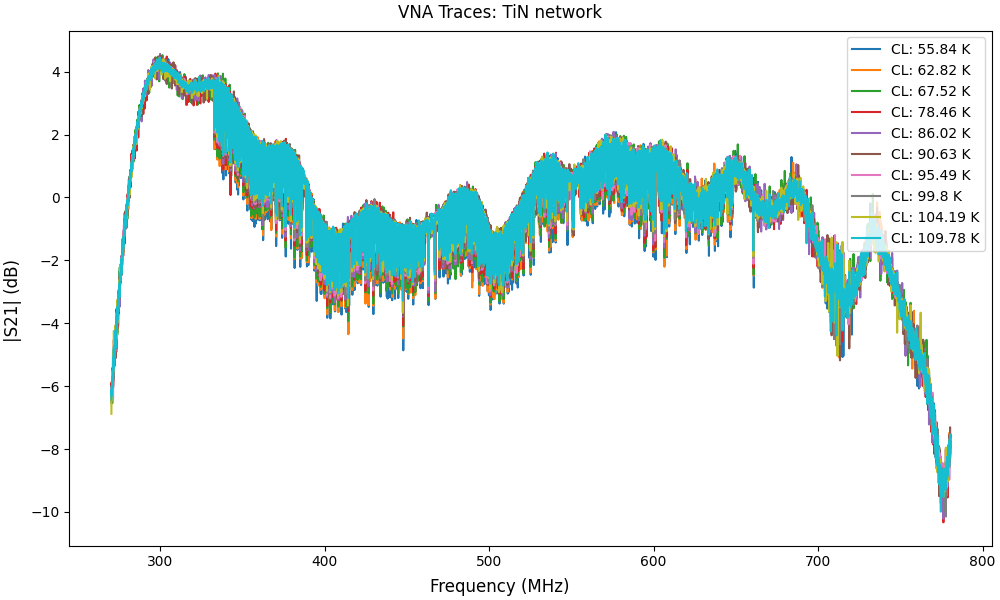

In [63]:
att_target = 0
drone_target = 4

drone_key = f'B1D{drone_target}'

try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_vna)
except:
    print("No figures currently open")

fig_vna, axes = plt.subplots(1, 1, figsize = (10, 6), constrained_layout = True)

Tlist = []
for date in date_sess_pairs.keys():
    for sess_id in date_sess_pairs[date]:
        Masterlist = date_sess_pairs[date][sess_id]

        for mlist in [Masterlist]:#, Masterlist]:
            for i, tstamp in enumerate(mlist.keys()):
                coldload_temp = float(mlist[tstamp]['vna_cfgs']['ext_cfg']['coldload_temp'])
                array_temps = float(
                #print(tstamp, vna_dict['dr_cfg'][drone_key]['atten'])
                drive_atten = mlist[tstamp]['vna_cfgs']['dr_cfg'][drone_key]['atten']['drive']
                sense_atten = mlist[tstamp]['vna_cfgs']['dr_cfg'][drone_key]['atten']['sense']
                #tone_power = targ_dict['dr_cfg'][drone_key]['tones']['tone_powers'][0]
                num_tones = 1000#len(Masterlist['1733492417']['vna_cfgs']['dr_cfg'][drone_key]['det_config']['found_detector_freqs'])
                material = mlist[tstamp]['vna_cfgs']['dr_cfg'][drone_key]['det_config']['detector_type']
    
                for T in Tlist:
                    if np.abs(coldload_temp-T)<4:
                        drive_atten=1000
                        
                if drive_atten == att_target:
                    fname = mlist[tstamp]['vna_files']['data_files'][drone_key][0]
                    Tlist.append(coldload_temp)
                    fs, s21z = plot_sweep(fname, figax = (fig_vna, axes), 
                                          label = f'CL: {np.round(coldload_temp,2)} K', n = 3, fix_offset=True)

fig_vna.supxlabel("Frequency (MHz)")
fig_vna.supylabel("|S21| (dB)")
fig_vna.suptitle(f"VNA Traces: {material} network")

Target sweeps below

Text(0.5, 0.98, 'VNA Traces: TiN network')

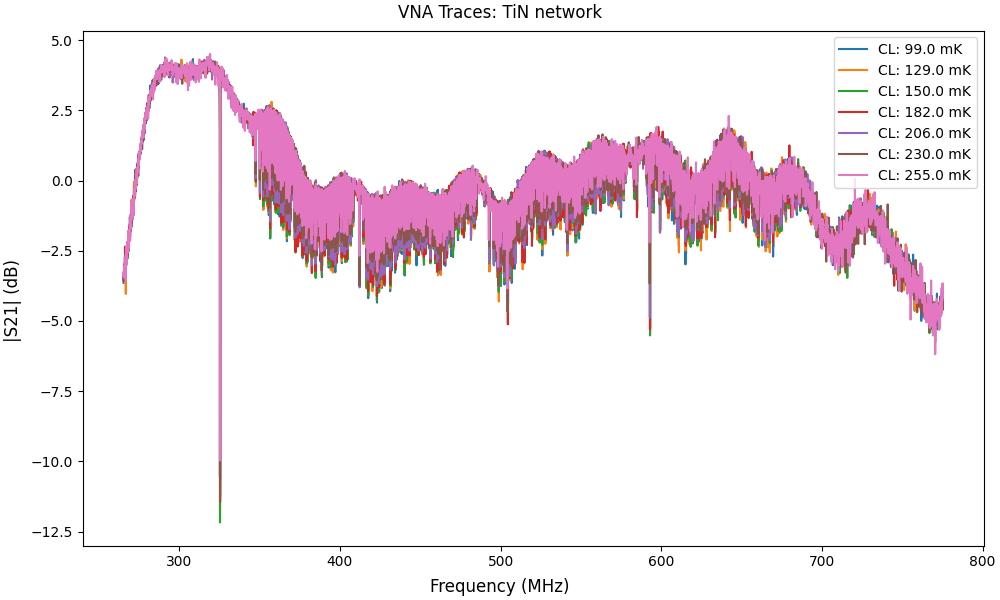

In [72]:
att_target = 0
drone_target = 3

drone_key = f'B1D{drone_target}'

try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_vna)
except:
    print("No figures currently open")

fig_vna, axes = plt.subplots(1, 1, figsize = (10, 6), constrained_layout = True)


Tlist = []

for mlist in [Masterlist]:#, Masterlist]:
    for i, tstamp in enumerate(mlist.keys()):
        coldload_temp = float(mlist[tstamp]['vna_cfgs']['ext_cfg']['coldload_temp'])
        array_temps = float(np.array(mlist[tstamp]['vna_cfgs']['ext_cfg']['array_temp'])[0])*1000
        #print(tstamp, vna_dict['dr_cfg'][drone_key]['atten'])
        drive_atten = mlist[tstamp]['vna_cfgs']['dr_cfg'][drone_key]['atten']['drive']
        sense_atten = mlist[tstamp]['vna_cfgs']['dr_cfg'][drone_key]['atten']['sense']
        #tone_power = targ_dict['dr_cfg'][drone_key]['tones']['tone_powers'][0]
        num_tones = 1000#len(Masterlist['1733492417']['vna_cfgs']['dr_cfg'][drone_key]['det_config']['found_detector_freqs'])
        material = mlist[tstamp]['vna_cfgs']['dr_cfg'][drone_key]['det_config']['detector_type']
    
        for T in Tlist:
            if np.abs(array_temps-T)<4:
                drive_atten=1000
                
        if drive_atten == att_target:
            fname = mlist[tstamp]['vna_files']['data_files'][drone_key][0]
            Tlist.append(array_temps)
            fs, s21z = plot_sweep(fname, figax = (fig_vna, axes), 
                                    label = f'CL: {np.round(array_temps)} mK', n = 3, fix_offset=True)

fig_vna.supxlabel("Frequency (MHz)")
fig_vna.supylabel("|S21| (dB)")
fig_vna.suptitle(f"VNA Traces: {material} network")

2000000.0


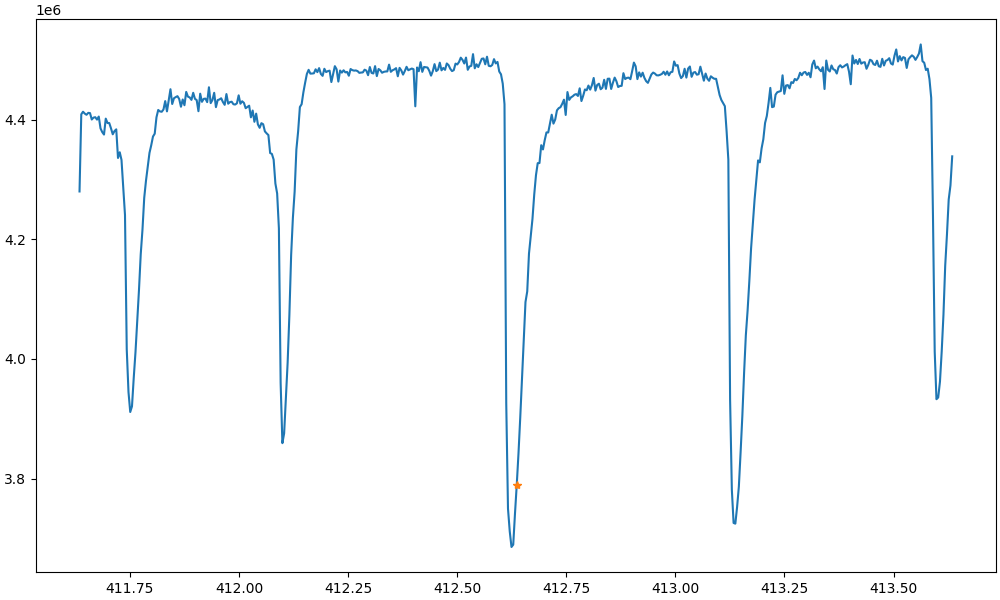

In [395]:
fname = targ_dict['targ_files']['data_files'][drone_key][0]
fs, s21z = np.load(fname)
bin_num = 184
win1, win2 = (bin_num*500, (bin_num+1)*500)

fig_temp, axes = plt.subplots(1, 1, figsize = (10, 6), constrained_layout = True)
axes.plot(fs[win1:win2].real*1e-6, np.abs(s21z[win1:win2]))
axes.plot(fs[win1+250].real*1e-6, np.abs(s21z[win1 + 250]), "*")

print(fs[win2-1].real -fs[win1].real)

Text(0.5, 0.98, 'VNA Traces: TiN network')

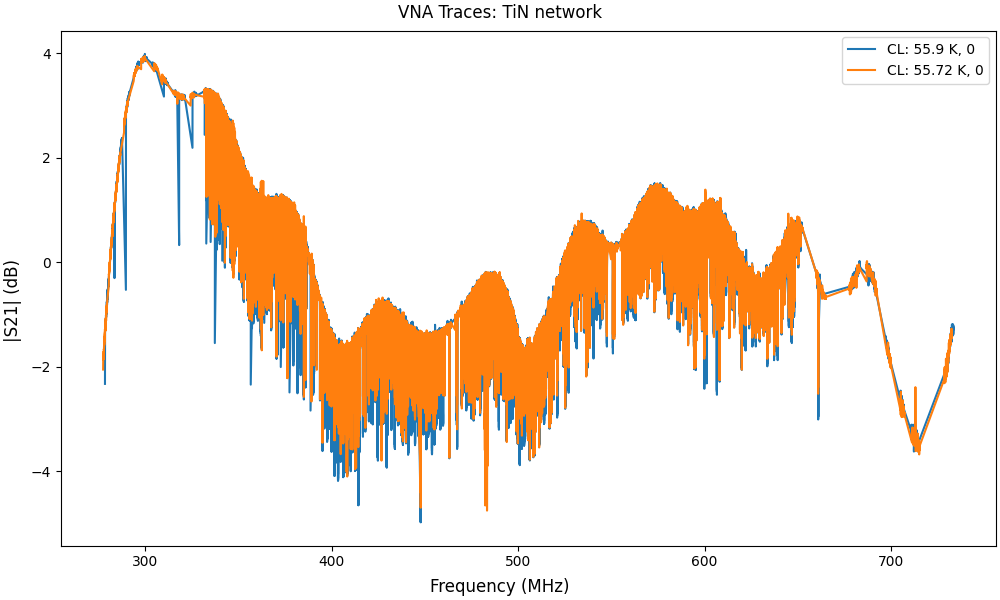

In [393]:
att_target = 0
drone_target = 4
drone_key = f'B1D{drone_target}'

try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_targ)
except:
    print("No figures currently open")

fig_targ, axes = plt.subplots(1, 1, figsize = (10, 6), constrained_layout = True)

#Tlist = []

for mlist in [Masterlist]:#, Masterlist]:
    for i, tstamp in enumerate(mlist.keys()):
        tstamp_dict = mlist[tstamp]
        targs = tstamp_dict['targ_dict'].keys()
        for targ in targs:
            targ_dict = tstamp_dict['targ_dict'][targ]
            coldload_temp = targ_dict['targ_cfgs']['ext_cfg']['coldload_temp']
            drive_atten = targ_dict['targ_cfgs']['dr_cfg'][drone_key]['atten']['drive']
            sense_atten = targ_dict['targ_cfgs']['dr_cfg'][drone_key]['atten']['sense']
            if sense_atten>0:
                continue
            #tone_power = targ_dict['dr_cfg'][drone_key]['tones']['tone_powers'][0]
            num_tones = targ_dict['targ_cfgs']['dr_cfg'][drone_key]['det_config']['found_num_detectors']
            material = targ_dict['targ_cfgs']['dr_cfg'][drone_key]['det_config']['detector_type']
    
            for T in Tlist:
                if np.abs(coldload_temp-T)<2:
                    continue#drive_atten=1000
                
            if drive_atten == att_target:
                fname = targ_dict['targ_files']['data_files'][drone_key][0]
                Tlist.append(coldload_temp)
                fs, s21z = plot_sweep(fname, figax = (fig_targ, axes), 
                                      label = f'CL: {np.round(coldload_temp,2)} K, {sense_atten}', n = 3, fix_offset=True)

fig_targ.supxlabel("Frequency (MHz)")
fig_targ.supylabel("|S21| (dB)")
fig_targ.suptitle(f"VNA Traces: {material} network")

In [352]:
Masterlist['1733492417']['targ_dict']['1733492848']['targ_cfgs']['dr_cfg'][drone_key]['tones']

{'NCLO': 520,
 'bandwidth': 0.75,
 'N_step': 500,
 'dB': True,
 'num_tones': 552,
 'tone_freqs': [265353515.625,
  280642578.125,
  282683105.46875,
  294919921.875,
  296959472.65625,
  298999023.4375,
  303078613.28125,
  304098144.53125,
  307157714.84375,
  312256835.9375,
  316335937.5,
  317355957.03125,
  319395507.8125,
  322455078.125,
  325292480.46875,
  334692871.09375,
  342851562.5,
  345949707.03125,
  347708984.375,
  348970214.84375,
  350287597.65625,
  351986816.40625,
  352331054.6875,
  352478027.34375,
  352689941.40625,
  353618652.34375,
  353874023.4375,
  354803222.65625,
  355755371.09375,
  356592285.15625,
  356888671.875,
  357214843.75,
  357639648.4375,
  358109375.0,
  358228515.625,
  358993652.34375,
  359322753.90625,
  359591308.59375,
  360074707.03125,
  360418457.03125,
  360916992.1875,
  361474609.375,
  362088867.1875,
  362229003.90625,
  362494628.90625,
  363100585.9375,
  363552246.09375,
  364784667.96875,
  365524414.0625,
  365990234.37

KeyError: '1733492417'

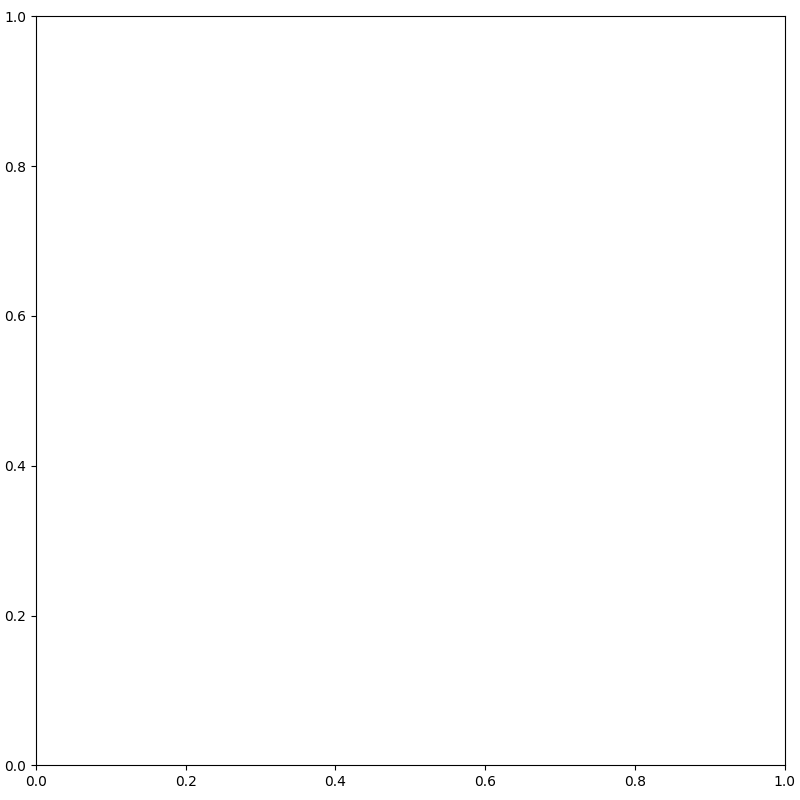

In [385]:
att_target = 0
drone_target = 4
drone_key = f'B1D{drone_target}'

try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_targ_rand)
except:
    print("No figures currently open")

fig_targ_rand, axes = plt.subplots(1, 1, figsize = (8, 8), constrained_layout = True)
#plt.close()
plt.gca().set_aspect('equal')
#Generate a random set of detectors
n = 3
NumTones = Masterlist['1733492417']['targ_dict']['1733492848']['targ_cfgs']['dr_cfg'][drone_key]['tones']['num_tones']
ToneFreqs = np.array(Masterlist['1733492417']['targ_dict']['1733492848']['targ_cfgs']['dr_cfg'][drone_key]['tones']['tone_freqs'])
N = [randint(0, NumTones-1) for i in range(n)]
bin_choices = ToneFreqs[N]


for mlist in [Masterlist]:#, Masterlist]:
    for i, tstamp in enumerate(mlist.keys()):
        tstamp_dict = mlist[tstamp]
        targs = tstamp_dict['targ_dict'].keys()
        for targ in targs:
            targ_dict = tstamp_dict['targ_dict'][targ]
            coldload_temp = targ_dict['targ_cfgs']['ext_cfg']['coldload_temp']
            drive_atten = targ_dict['targ_cfgs']['dr_cfg'][drone_key]['atten']['drive']
            sense_atten = targ_dict['targ_cfgs']['dr_cfg'][drone_key]['atten']['sense']
            if sense_atten>0:
                continue
            tone_power = targ_dict['targ_cfgs']['dr_cfg'][drone_key]['tones']['tone_powers'][0]
            tone_freqs = np.array(targ_dict['targ_cfgs']['dr_cfg'][drone_key]['tones']['tone_freqs'])
            material = targ_dict['targ_cfgs']['dr_cfg'][drone_key]['det_config']['detector_type']
                    
            if drive_atten == att_target:
                fname = targ_dict['targ_files']['data_files'][drone_key][0]
                fs, s21z = np.load(fname)
                for det in bin_choices:
                    bin_num = np.where(np.abs(tone_freqs - det) == np.abs(tone_freqs - det).min())[0][0]
                    win1, win2 = (bin_num*500, (bin_num+1)*500)
                    det_hope = s21z[win1:win2]
                    det_hope = det_hope / np.mean(det_hope)
                    axes.plot(det_hope.real, det_hope.imag, label = f'CL: {np.round(coldload_temp, 2)} K')
    


fig_targ.supxlabel("Frequency (MHz)")
fig_targ.supylabel("|S21| (dB)")
fig_targ.suptitle(f"VNA Traces: {material} network")

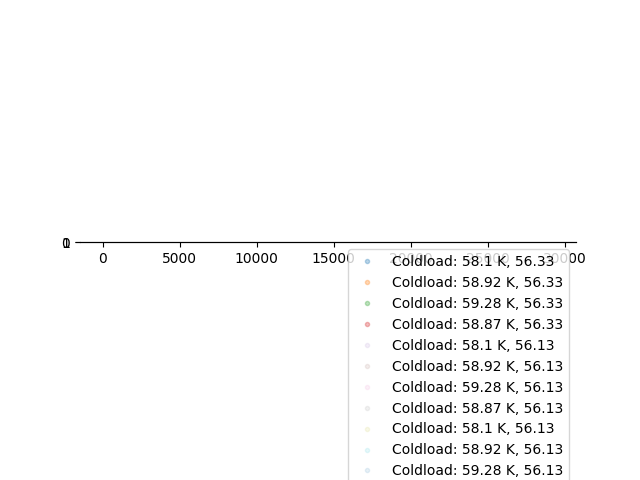

In [198]:
att_target = 0
drone_target = 2
drone_key = f'B1D{drone_target}'

try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_vna)
except:
    print("No figures currently open")
#plt.close()
plt.gca().set_aspect('equal')

#get initial data
tbase = all_timestamps['vna'][0]
vna_dict, targ_dict, stream_dict = collect_all_files(tbase, all_timestamps, cfg_dir)
tones = stream_dict['dr_cfg'][drone_key]['tones']['tone_freqs']
found_det_freqs = np.array(stream_dict['dr_cfg'][drone_key]['det_config']['found_detector_freqs'])

N = [randint(0, len(found_det_freqs)-1) for i in range(1)]

random_dets = found_det_freqs[N]

for i, tstamp in enumerate(all_timestamps['vna']):
    if i%4==0:
        vna_dict, targ_dict, stream_dict = collect_all_files(tstamp, all_timestamps, cfg_dir)
    else:
        continue
    
    array_temp = stream_dict['ext_cfg']['array_temp'][0]
    coldload_temp = stream_dict['ext_cfg']['coldload_temp']
    tone_power = stream_dict['dr_cfg'][drone_key]['tones']['tone_powers'][0]
    drive_atten = stream_dict['dr_cfg'][drone_key]['atten']['drive']
    tones = stream_dict['dr_cfg'][drone_key]['tones']['tone_freqs']
    found_det_freqs = np.array(stream_dict['dr_cfg'][drone_key]['det_config']['found_detector_freqs'])
    nearest_freqs = np.array([])
    for samp_det in random_dets:
        near = np.where(np.abs(tones - samp_det)==np.min(np.abs(tones - samp_det))) 
        #nearest_freqs= np.append(nearest_freqs, found_det_freqs[near[0][0]])
    
    fnames = stream_dict['data_files'][drone_key]
    
    for samp_tone in near:
        noise_data = np.array([])
        for fname in fnames:
            data = np.load(fname)
            noise_data = np.append(noise_data, data[samp_tone])
        
        data = noise_data/noise_data.mean()
        plt.plot(data.real, data.imag, ".", alpha = 0.1, label = f'Coldload: {np.round(coldload_temp,2)} K, {np.round(tone_power,2)}')
plt.legend()
plt.show()

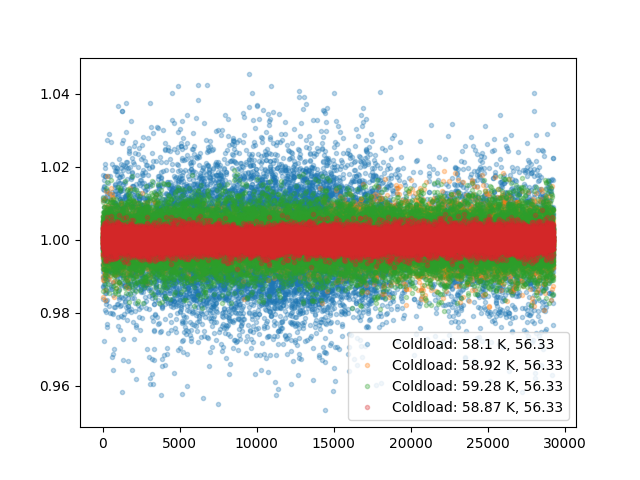

In [174]:
att_target = 0
drone_target = 1
drone_key = f'B1D{drone_target}'

plt.close()
#plt.gca().set_aspect('equal')

try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_vna)
except:
    print("No figures currently open")

#get initial data
tbase = all_timestamps['vna'][0]
vna_dict, targ_dict, stream_dict = collect_all_files(tbase, all_timestamps, cfg_dir)
tones = stream_dict['dr_cfg'][drone_key]['tones']['tone_freqs']
found_det_freqs = np.array(stream_dict['dr_cfg'][drone_key]['det_config']['found_detector_freqs'])

N = [randint(0, len(found_det_freqs)-1) for i in range(1)]

random_dets = found_det_freqs[N]

for i, tstamp in enumerate(all_timestamps['vna']):
    if i%4==0:
        vna_dict, targ_dict, stream_dict = collect_all_files(tstamp, all_timestamps, cfg_dir)
    else:
        continue
    
    array_temp = stream_dict['ext_cfg']['array_temp'][0]
    coldload_temp = stream_dict['ext_cfg']['coldload_temp']
    tone_power = stream_dict['dr_cfg'][drone_key]['tones']['tone_powers'][0]
    drive_atten = stream_dict['dr_cfg'][drone_key]['atten']['drive']
    tones = stream_dict['dr_cfg'][drone_key]['tones']['tone_freqs']
    found_det_freqs = np.array(stream_dict['dr_cfg'][drone_key]['det_config']['found_detector_freqs'])
    nearest_freqs = np.array([])
    for samp_det in random_dets:
        near = np.where(np.abs(tones - samp_det)==np.min(np.abs(tones - samp_det))) 
        #nearest_freqs= np.append(nearest_freqs, found_det_freqs[near[0][0]])
    
    fnames = stream_dict['data_files'][drone_key]
    
    for samp_tone in near:
        noise_data = np.array([])
        for fname in fnames:
            data = np.load(fname)
            noise_data = np.append(noise_data, data[samp_tone])
        
        data = noise_data/noise_data.mean()
        plt.plot(np.abs(data), ".", alpha = 0.3, label = f'Coldload: {np.round(coldload_temp,2)} K, {np.round(tone_power,2)}')
plt.legend()
plt.show()

In [176]:
t0 55.6 @ 7:40
t1 60.9 @ 8:10
t2 64.6 @ 8:40
t3 69.44 @ 9:40

487.76666666666665

In [436]:
def calc_load(T0, T1, T2, t1):
    dT1 = T1 - T0
    dT2 = T2 - T0
    x = dT2/dT1 - 1
    r = -np.log(x)/t1
    tau = 1/r
    dTf = dT1/(1 - np.exp(-r*t1))
    Tf = dTf + T0
    return tau, Tf

In [438]:
print(calc_load(80.6, 83.16, 85.4, 15))

(112.33313534128182, 101.08000000000045)


In [439]:
((1.7)*(1-np.exp(-3/11)) + (1.3)*(1-np.exp(-1/11)) )# + 0.81*(1-np.exp(-3/18)))*

0.5187584114483733

1.7 1.3
1.9011361671469575 1.6227939673904543
1.8162679372695274 1.5778330598012145
1.7139503032770138 1.5146887278224075
1.6589130801251957 1.478617147679653
1.608289994879512 1.4445443805597722
1.5746586116535428 1.4215176498078914
1.5290749635506904 1.3898808544799397


In [19]:
30 minutes at 2.89x
10 minutes at 1.69 times
2 minutes at 0.81 times
25 minutes at 1 times (with checking)

reasonable values
0.05 (~2K)
0.2 (~20+K)

Perhaps pick things dispersed between 0.07 and 0.5 equally distributed logarythmically with 10 points (maybe going higher)


also need to fix the target sweep bandwidth
check tone powers again
change order of operations in script to make it take a bunch of vna/targ sweeps then fit some random number of detectors and check
to find the optimal tone powers

Got it


In [255]:
psu.set_current(channel = 1, current = 0.002)

OCSReply: OK : Operation "set_current" is currently not running (SUCCEEDED).
  set_current[session=116]; status=done without error 0.005392 s ago, took 0.203379 s
  messages (3 of 3):
    1733623446.697 Status is now "starting".
    1733623446.899 Set channel 1 current to 0.002
    1733623446.900 Status is now "done".
  other keys in .session: op_code, data

In [467]:
for i in range(10):
    status,msg,session = coldload_agent.acq.status()
    print(session['data']['fields']['Channel_2']['T'])
    time.sleep(0.5)

78.562
78.456
78.563
78.457
78.562
78.457
78.457
78.564
78.457
78.563


In [461]:
coldload_agent.set_values.start(channel =2, range = 4)

OCSReply: OK : Started task "set_values".
  set_values[session=4]; status=starting for 0.007748 s
  messages (1 of 1):
    1733774079.489 Status is now "starting".
  other keys in .session: op_code, data

In [401]:
[0, .079, .11, .137, .158, .177, .194, .21, .224]
[55.8, ?, 62.95, 66.83, 70.4, 73.2,  

18.5

In [402]:
[0, .11, .137, .158, .177, .205 
[55.8, 62.95, 66.83, 70.4, 73.2, 78.51

27.0

In [421]:
curs = np.array([.11, .137, .158, .177, .205])
temps = np.array([62.95, 66.83, 70.4, 73.2, 78.51]) - 55.8


11.030000000000001

In [526]:
psu.set_current(channel=1, current=.224)#.224

OCSReply: OK : Operation "set_current" is currently not running (SUCCEEDED).
  set_current[session=266]; status=done without error 0.005632 s ago, took 0.203509 s
  messages (3 of 3):
    1733781677.676 Status is now "starting".
    1733781677.879 Set channel 1 current to 0.224
    1733781677.880 Status is now "done".
  other keys in .session: op_code, data

{'Voltage_1': 4.234, 'Current_1': 0.223, 'Voltage_2': 0.0, 'Current_2': 0.0, 'Voltage_3': 0.0, 'Current_3': 0.0}


OCSReply: OK : Requested stop on process monitor_output".
  monitor_output[session=264]; status=running for 72.3 s
  messages (2 of 2):
    1733778745.911 Status is now "starting".
    1733778745.912 Status is now "running".
  other keys in .session: op_code, data

In [477]:
current_target
temperature_target

KeyError: 'data'

In [509]:
import yaml

In [532]:
yaml_file = "./ccatkidlib/scripts/modcam_coldload/coldload_tuning_params.yaml"

In [557]:

with open(yaml_file, "r") as file:
    results = yaml.safe_load(file)

In [560]:
results

{'completed': [0, 0.079, 0.11, 0.137, 0.158, 0.177, 0.205],
 'currents': [0.224, 0.248, 0.271],
 'stage1': {'current_factor': 1.5, 'nominal_hold_time': 15},
 'stage2': {'current_factor': 1.1, 'nominal_hold_time': 5},
 'stage3': {'current_factor': 1, 'nominal_hold_time': 10},
 'steps_remaining': 3,
 'temps': [82.09, 87.07, 92.1]}

In [561]:
yfile = open(yaml_file, "w")
yaml.dump(results, yfile)
yfile.close()

/mnt/md0/bath_sweep_data/rfsoc:
20241211/

/mnt/md0/bath_sweep_data/targ:
20241211/

/mnt/md0/bath_sweep_data/timestream:
20241211/

/mnt/md0/bath_sweep_data/vna:
20241211/


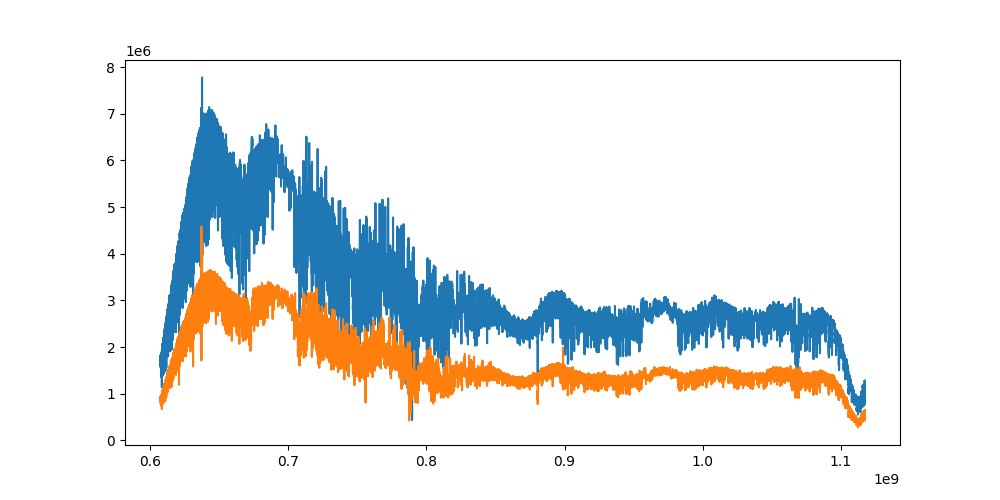

In [19]:
datadir = "mnt/md0/baseline_data/vna/20241214/1734148724/"
drone = "B1D1/"
files = glob.glob(datadir + drone+ "*npy")

plt.figure(figsize=(10,5))

#fig_targ_rand, axes = plt.subplots(1, 1, figsize = (8, 8), constrained_layout = True)
for file in files:
    freq, s21 = np.load(file)
    f = freq.real
    db = np.abs(s21)
    plt.plot(f, db, label = file)
plt.show()
plt.legend()

18.333333333333332